<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>PCA Visualization on the Iris Dataset</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Use PCA on a real dataset that has more than 3 features</li>
<li>Bring the 4 Iris features down to 2 principal components</li>
<li>Plot all three species together in a single 2D scatter</li>
<li>Use a scree plot to see how much variance each component keeps</li>
</ol>
The Iris dataset has 4 features so we cannot just plot it, we would need a 4D graph. This is exactly the kind of thing PCA is good at, it lets us bring 4 dimensions down to 2 while keeping most of the structure so we can finally see how the three species separate.
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Loading the Iris dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
The classic Iris dataset. It has 150 samples, 4 features (sepal length, sepal width, petal length, petal width) and 3 species (setosa, versicolor, virginica).
</div>

In [2]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Shape of data:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

Shape of data: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why we cannot just plot it</b>
</h2>
<div style="font-family:'Times New Roman';">
With 4 features we would need 4 axes. We could plot pairs of features but each pair only shows part of the story. PCA mixes all 4 features into 2 new axes that capture the most variation overall, so it is like the best possible 2D summary of the data.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 1 standardize the features</b>
</h2>
<div style="font-family:'Times New Roman';">
PCA cares about variance so a feature with big numbers would dominate just because of its units. Standardizing brings every feature to mean 0 and std 1 so they are treated fairly.
</div>

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling:", X_scaled.mean(axis=0).round(2))
print("Std after scaling :", X_scaled.std(axis=0).round(2))

Mean after scaling: [-0. -0. -0. -0.]
Std after scaling : [1. 1. 1. 1.]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 2 apply PCA (4D to 2D)</b>
</h2>
<div style="font-family:'Times New Roman';">
We ask PCA for 2 components and transform the data. Each sample which had 4 features now becomes just 2 numbers, PC1 and PC2.
</div>

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape :", X_pca.shape)

Original shape: (150, 4)
Reduced shape : (150, 2)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 3 plotting the two components</b>
</h2>
<div style="font-family:'Times New Roman';">
Now we can finally see all three species in one plot. Each point is a flower placed by its two principal components and colored by its real species.
</div>

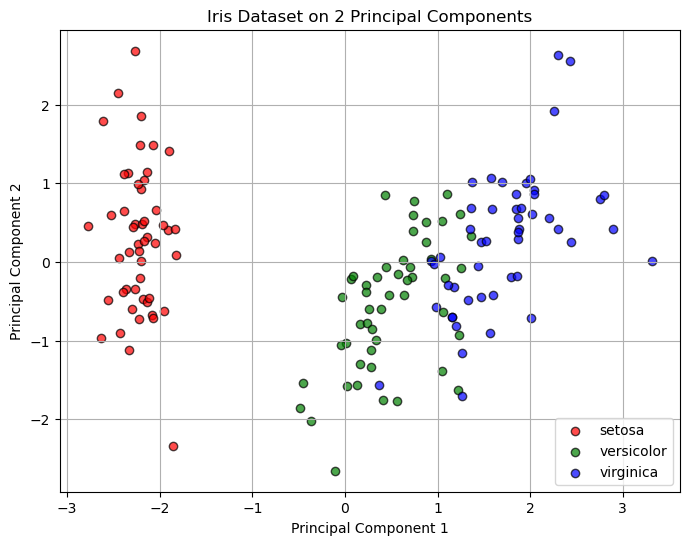

In [5]:
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],
                color=colors[i], label=target_name,
                alpha=0.7, edgecolors='k')

plt.title("Iris Dataset on 2 Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>How much variance did we keep?</b>
</h2>
<div style="font-family:'Times New Roman';">
The explained_variance_ratio_ gives the fraction of total variance each PC keeps. For Iris the first two components together keep around 95% which is why the 2D plot looks so clean.
</div>

In [6]:
explained = pca.explained_variance_ratio_

for i, ratio in enumerate(explained):
    print(f"PC{i+1} keeps {ratio*100:.2f}% of the variance")

print(f"\nTwo components together keep {explained.sum()*100:.2f}% of the total variance")

PC1 keeps 72.96% of the variance
PC2 keeps 22.85% of the variance

Two components together keep 95.81% of the total variance


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Scree plot</b>
</h2>
<div style="font-family:'Times New Roman';">
A scree plot shows the variance kept by each component and also the running total. It helps decide how many components are enough. Let me fit PCA with all 4 components to see the full picture.
</div>

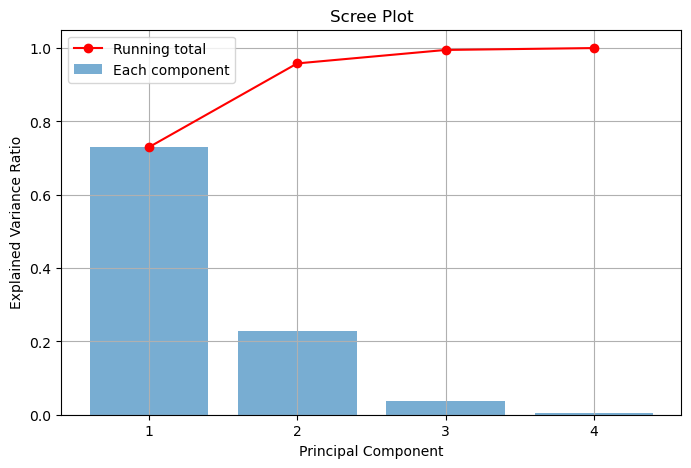

PC1: 72.96%  (running total: 72.96%)
PC2: 22.85%  (running total: 95.81%)
PC3: 3.67%  (running total: 99.48%)
PC4: 0.52%  (running total: 100.00%)


In [7]:
pca_full = PCA().fit(X_scaled)
explained_full = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained_full)
components = range(1, len(explained_full) + 1)

plt.figure(figsize=(8, 5))
plt.bar(components, explained_full, alpha=0.6, label='Each component')
plt.plot(components, cumulative, marker='o', color='red', label='Running total')

plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(list(components))
plt.legend()
plt.grid(True)
plt.show()

for i, (ind, cum) in enumerate(zip(explained_full, cumulative)):
    print(f"PC{i+1}: {ind*100:.2f}%  (running total: {cum*100:.2f}%)")

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Bonus what do the components actually mean?</b>
</h2>
<div style="font-family:'Times New Roman';">
Each principal component is a weighted mix of the original 4 features. The weights are called loadings and they tell which features that PC depends on the most. For Iris, PC1 leans mostly on the petal measurements, which makes sense because petals are what separate the species the most.
</div>

In [8]:
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=feature_names)

print("How much each feature contributes to each component:\n")
print(loadings.round(3))

How much each feature contributes to each component:

                     PC1    PC2
sepal length (cm)  0.521  0.377
sepal width (cm)  -0.269  0.923
petal length (cm)  0.580  0.024
petal width (cm)   0.565  0.067


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Used PCA on the real Iris dataset and brought 4 features down to 2</li>
<li>Standardized first because PCA is sensitive to feature scale</li>
<li>Plotted all 3 species in one 2D scatter, setosa separates very cleanly while versicolor and virginica overlap a bit</li>
<li>Used the explained variance ratio and a scree plot to confirm 2 components keep around 95% of the information</li>
<li>Looked at the loadings and saw the petal features drive PC1</li>
</ul>
PCA turned a dataset we could not even plot into a clear 2D picture while keeping almost all the information. That finishes the PCA part, from intuition, to building it from scratch, to using it on real data.
</div>